# March Madness 2026 — NCAA Tournament Prediction
## EMBA 693R Advanced Machine Learning Final Project

End-to-end pipeline to predict NCAA tournament game outcomes and scores using team efficiency metrics, coaching analytics, player data, and historical tournament results.

**What we're predicting (three targets):**

| Target | Type | Used In | Why it matters |
|--------|------|---------|----------------|
| `score_margin` | Continuous (Team A − Team B) | OLS / regression | Predict *by how much* the favored team wins; positive = Team A won. |
| `game_result` | Binary (1 = Team A wins) | Classification | Predict *who* wins (for bracket picks). |
| `total_points` | Continuous (combined score) | Score model | Predict total points (e.g. over/under). |

**Phase 1 (this section): Data Acquisition** — fetch all data sources and assemble the matchup-level modeling dataset. Each row = one past tournament game, with features for both teams so we can train models to predict the three targets.

**Phase 2 (next): Modeling & Evaluation** — explore key relationships, build baseline and ML models, and compare them to simple strategies like always picking the better seed.

---
## 0. Environment Setup
Run this cell once to install all required packages.

---
## Phase 1: Data Acquisition

### 1.1 Imports & Configuration

In [110]:
# Data manipulation (pandas), math (numpy), and HTTP requests for downloading data
import pandas as pd
import numpy as np
import requests
import time
import io
import os
import warnings
import json
from pathlib import Path
from tqdm.auto import tqdm
from rapidfuzz import process as rfprocess, fuzz

warnings.filterwarnings('ignore')
print("Libraries loaded.")

# ─── Configuration ────────────────────────────────────────────────
# Fix the random seed so any random steps (e.g. train/test split, sampling) are reproducible.
# Same seed → same results every run (important for grading and debugging).
RANDOM_STATE   = 42
np.random.seed(RANDOM_STATE)

# SEASONS: every year we need team ratings from Barttorvik (including 2026 for prediction).
# TOURN_SEASONS: only years that have *finished* tournament games. We use those games as
# training labels. 2026 tournament hasn't been played yet, so we don't have outcomes for it.
SEASONS        = list(range(2011, 2027))   # 2011–2026 inclusive (for features)
TOURN_SEASONS  = list(range(2011, 2026))   # 2011–2025 only (for training targets)

# Data directories: raw downloads and cached processed tables
DATA_DIR       = Path("data/")
KAGGLE_DIR     = DATA_DIR / "kaggle"
CACHE_DIR      = DATA_DIR / "cache"

for d in [DATA_DIR, KAGGLE_DIR, CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Data directory: {DATA_DIR.resolve()}")
print(f"Seasons: {SEASONS[0]}–{SEASONS[-1]}  ({len(SEASONS)} seasons)")

Libraries loaded.
Data directory: G:\My Drive\Colab Notebooks\march_madness\data
Seasons: 2011–2026  (16 seasons)


### 1.2 Helper Functions

In [111]:
# Simple flag for "power" leagues. You can adjust this list if you want a different definition.
POWER6_CONFS = {"ACC", "B10", "B12", "P12", "SEC", "BE"}

def is_power6_conf(conf):
    """Return 1 if conference is in the power‑6 set, else 0 (handles NaN/unknown)."""
    if isinstance(conf, str):
        return 1 if conf in POWER6_CONFS else 0
    return 0

In [112]:
# Simple flag for "power" leagues. You can adjust this set if you want a different definition.
POWER6_CONFS = {"ACC", "B10", "B12", "P12", "SEC", "BE"}

def is_power6_conf(conf):
    """Return 1 if conference is in the power‑6 set, else 0 (handles NaN/unknown)."""
    if isinstance(conf, str):
        return 1 if conf in POWER6_CONFS else 0
    return 0

# Simple round buckets (early vs late). Can refine later if needed.
def is_late_round(daynum):
    """Return 1 for roughly Sweet16 and beyond, else 0. Uses DayNum as a proxy for round."""
    try:
        d = float(daynum)
    except (TypeError, ValueError):
        return 0
    return 1 if d >= 143 else 0  # based on typical NCAA DayNum cut points.

In [113]:
# ─── safe_request: GET a URL with retries and backoff ────────────────────────────────
# If the server is busy or the network blips, we wait longer each retry (delay * attempt)
# so we don't hammer the site. Statistically, a few independent tries reduce the chance
# of failing entirely due to bad luck.
def safe_request(url, retries=3, delay=1.5, timeout=20, **kwargs):
    """GET request with retry logic and rate-limit backoff."""
    for attempt in range(retries):
        try:
            resp = requests.get(url, timeout=timeout, **kwargs)
            resp.raise_for_status()
            return resp
        except Exception as e:
            if attempt < retries - 1:
                time.sleep(delay * (attempt + 1))
            else:
                print(f"  [WARN] Failed after {retries} attempts: {url}\n         {e}")
    return None


# ─── load_or_fetch: use cache to avoid re-downloading or re-computing ─────────────────
# If the CSV already exists, we load it. Otherwise we call fetch_fn() and save the result.
# This way re-running the notebook doesn't re-hit the API every time (faster, nicer to servers).
def load_or_fetch(cache_path, fetch_fn, force_refresh=False):
    """
    Load from CSV cache if it exists, otherwise call fetch_fn() to build it.
    This prevents redundant API calls when re-running cells.
    """
    cache_path = Path(cache_path)
    if cache_path.exists() and not force_refresh:
        df = pd.read_csv(cache_path, low_memory=False)
        print(f"  [CACHE] Loaded {len(df):,} rows from {cache_path.name}")
        return df
    df = fetch_fn()
    if df is not None and len(df) > 0:
        df.to_csv(cache_path, index=False)
        print(f"  [SAVED] {len(df):,} rows → {cache_path.name}")
    return df


# ─── add_diff_features: turn Team A and Team B columns into one "advantage" column ───
# For modeling, we often want one number per game: how much better is Team A than B on this metric?
# Example: a_adj_o - b_adj_o = adj_o_diff. Positive means Team A scores more per 100 possessions.
# Models learn from these diffs (e.g. "when adj_em_diff is large, Team A usually wins").
def add_diff_features(df, a_cols, b_cols):
    """
    For every matching pair (a_col, b_col), compute a_col - b_col
    and add it as a new column with suffix _diff.
    a_cols and b_cols must be parallel lists of column names.
    """
    for ac, bc in zip(a_cols, b_cols):
        base = ac.replace('_a_', '_').replace('_teamA_', '_')
        diff_col = base + '_diff'
        df[diff_col] = df[ac] - df[bc]
    return df


# ─── normalize_bart_columns: same metric, different column names by year ─────────────
# Barttorvik changed header names over the years (e.g. "AdjOE" vs "adjoe"). We map all
# variants to one standard name so the rest of the code doesn't break across seasons.
def normalize_bart_columns(df):
    """
    Standardize Barttorvik CSV column names across seasons.
    Column headers changed in some years; this maps them to a consistent schema.
    """
    rename_map = {
        # Team identity
        'team':       'team',
        'Team':       'team',
        'TEAM':       'team',
        'conf':       'conf',
        'Conf':       'conf',
        'Conf.':      'conf',
        # Core efficiency — title-case variants (older URLs / trank.php)
        'AdjOE':      'adj_o',
        'Adj OE':     'adj_o',
        'AdjDE':      'adj_d',
        'Adj DE':     'adj_d',
        'Barthag':    'barthag',
        'BARTHAG':    'barthag',
        'Adj T.':     'adj_t',
        'AdjTempo':   'adj_t',
        'Tempo':      'adj_t',
        # Core efficiency — lowercase variants (team_results.csv format)
        'adjoe':      'adj_o',
        'adjde':      'adj_d',
        'adjt':       'adj_t',
        # Four Factors – offense
        'EFG%':       'off_efg',
        'eFG%':       'off_efg',
        'TOR':        'off_to',
        'TO%':        'off_to',
        'ORB':        'off_or',
        'OR%':        'off_or',
        'FTR':        'off_ftr',
        # Four Factors – defense
        'EFGD%':      'def_efg',
        'eFGD%':      'def_efg',
        'TORD':       'def_to',
        'TOD%':       'def_to',
        'DRB':        'def_or',
        'DR%':        'def_or',
        'FTRD':       'def_ftr',
        # Shooting
        '2P%':        'fg2_pct',
        '2P%D':       'fg2d_pct',
        '3P%':        'fg3_pct',
        '3P%D':       'fg3d_pct',
        # Misc
        'WAB':        'wab',
        'Rk':         'bart_rank',
        'rank':       'bart_rank',
        'G':          'games',
        'Rec':        'record',
        'W-L':        'record',
    }
    df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})
    return df


print("Helper functions defined.")

Helper functions defined.


---
### 1.3 Barttorvik Team Efficiency Metrics (2011–2026)

Fetches adjusted offensive/defensive efficiency, Barthag, tempo, and Four Factors for every D1 team in every season.  
Data source: **barttorvik.com** — free, no authentication required.  
Cache file: `data/cache/barttorvik_teams.csv`

**What these metrics mean (statistically):**
- **adj_o (Adjusted Offensive Efficiency):** Points scored per 100 possessions, adjusted for opponent and pace. Higher = better offense.
- **adj_d (Adjusted Defensive Efficiency):** Points allowed per 100 possessions, adjusted. *Lower* = better defense.
- **adj_em:** adj_o − adj_d. Net efficiency margin; positive = team outplays opponents on average.
- **barthag:** Probability that this team would beat an average D1 team on a neutral court (0–1). Derived from efficiency and variance.
- **adj_t (Adjusted Tempo):** Possessions per 40 minutes (pace). Used for context, not directly for win prediction.
- **Four Factors (eFG%, TO%, OR%, FTR):** Shooting, turnovers, rebounds, free throws — explain *why* efficiency is high or low.

In [114]:
# Barttorvik gives us *adjusted* (pace- and opponent-adjusted) team metrics. Raw points per game
# depend on tempo; adjusted metrics answer: "How many points would this team score/allow per 100
# possessions against an average D1 defense/offense?" That makes teams comparable across styles.
def fetch_barttorvik_season(year):
    """Download one season of Barttorvik team ratings. Returns DataFrame or None."""
    url = f"http://barttorvik.com/{year}_team_results.csv"
    resp = safe_request(url, retries=3, delay=1.0)
    if resp is None:
        print(f"  [WARN] Could not fetch {year}")
        return None
    try:
        text = resp.content.decode('utf-8-sig').strip()
        df = pd.read_csv(io.StringIO(text))
        if len(df) == 0:
            return None

        # Barttorvik CSV format changed over years: first column is sometimes rank (numeric),
        # sometimes a label. We detect and align so 'bart_rank' is always the first column.
        first_col = df.columns[0]
        if pd.to_numeric(df[first_col], errors='coerce').notna().mean() > 0.9:
            # Newer format: first column is numeric rank
            df = df.rename(columns={first_col: 'bart_rank'})
        else:
            # Older format: header has extra rank field but data rows don't —
            # shift column names right by one to realign
            new_cols = list(df.columns[1:]) + ['__drop__']
            df.columns = new_cols
            df = df.drop(columns='__drop__', errors='ignore')
            df.insert(0, 'bart_rank', range(1, len(df) + 1))

        df = normalize_bart_columns(df)
        df['season'] = year

        for col in ['adj_o', 'adj_d', 'barthag', 'adj_t', 'wab']:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')

        # adj_em = Adjusted Efficiency Margin. Offense minus defense: positive = outscore opponents
        # per 100 possessions. This single number summarizes overall team strength.
        if 'adj_o' in df.columns and 'adj_d' in df.columns:
            df['adj_em'] = df['adj_o'] - df['adj_d']

        return df

    except Exception as e:
        print(f"  [WARN] Parse error for {year}: {e}")
        return None


def fetch_all_barttorvik():
    frames = []
    for year in tqdm(SEASONS, desc="Barttorvik seasons"):
        df = fetch_barttorvik_season(year)
        if df is not None:
            frames.append(df)
        time.sleep(0.3)
    if not frames:
        raise RuntimeError("Could not download any Barttorvik data.")
    return pd.concat(frames, ignore_index=True)


bart_teams = load_or_fetch(
    CACHE_DIR / "barttorvik_teams.csv",
    fetch_all_barttorvik,
    force_refresh=True
)

print(f"\nBarttorvik dataset: {bart_teams.shape[0]:,} team-seasons × {bart_teams.shape[1]} columns")
print(f"Seasons: {bart_teams['season'].min()}–{bart_teams['season'].max()}")
print(f"Teams per season (avg): {bart_teams.groupby('season').size().mean():.0f}")
print(f"\nColumns: {list(bart_teams.columns)}")
bart_teams.head(3)

Barttorvik seasons: 100%|██████████| 16/16 [00:29<00:00,  1.86s/it]


  [SAVED] 5,657 rows → barttorvik_teams.csv

Barttorvik dataset: 5,657 team-seasons × 48 columns
Seasons: 2011–2026
Teams per season (avg): 354

Columns: ['bart_rank', 'team', 'conf', 'record', 'adj_o', 'oe Rank', 'adj_d', 'de Rank', 'barthag', 'rank.1', 'proj. W', 'Proj. L', 'Pro Con W', 'Pro Con L', 'Con Rec.', 'sos', 'ncsos', 'consos', 'Proj. SOS', 'Proj. Noncon SOS', 'Proj. Con SOS', 'elite SOS', 'elite noncon SOS', 'Opp OE', 'Opp DE', 'Opp Proj. OE', 'Opp Proj DE', 'Con Adj OE', 'Con Adj DE', 'Qual O', 'Qual D', 'Qual Barthag', 'Qual Games', 'FUN', 'ConPF', 'ConPA', 'ConPoss', 'ConOE', 'ConDE', 'ConSOSRemain', 'Conf Win%', 'wab', 'WAB Rk', 'Fun Rk, adjt', 'season', 'adj_em', 'Fun Rk', 'adj_t']


,bart_rank,team,conf,record,adj_o,oe Rank,adj_d,de Rank,barthag,rank.1,...,ConDE,ConSOSRemain,Conf Win%,wab,WAB Rk,"Fun Rk, adjt",season,adj_em,Fun Rk,adj_t
0,1,Ohio St.,B10,34-3,125.960692,1,91.842295,11,0.974240,1,...,1.019350,0.0,0.888889,11.689658,1,74.0,2011,34.118396,NaN,NaN
1,2,Kansas,B12,35-3,120.867644,4,90.961593,6,0.963349,2,...,0.990743,0.0,0.875000,10.217372,2,65.0,2011,29.906051,NaN,NaN
2,3,Duke,ACC,32-5,120.594748,5,91.472331,8,0.960021,3,...,0.931062,0.0,0.812500,9.288643,3,120.0,2011,29.122416,NaN,NaN


In [115]:
# Quick check: one season of Barttorvik data (e.g. 2014) — one row per team, same columns every year.
season = 2014
bart_test = bart_teams[bart_teams['season'] == season]
print(f"2014 season: {bart_test.shape[0]} teams")
bart_test.head(3)



2014 season: 351 teams


,bart_rank,team,conf,record,adj_o,oe Rank,adj_d,de Rank,barthag,rank.1,...,ConDE,ConSOSRemain,Conf Win%,wab,WAB Rk,"Fun Rk, adjt",season,adj_em,Fun Rk,adj_t
1037,1,Louisville,Amer,31-6,119.365263,10,88.220686,2,0.970026,1,...,0.906023,0.0,0.833333,5.384989,15,303.0,2014,31.144577,NaN,NaN
1038,2,Arizona,P12,33-5,116.732277,19,88.065052,1,0.962341,2,...,0.910256,0.0,0.833333,9.476381,2,129.0,2014,28.667225,NaN,NaN
1039,3,Florida,SEC,36-3,116.400541,20,89.060915,3,0.956007,3,...,0.927978,0.0,1.000000,11.769676,1,16.0,2014,27.339626,NaN,NaN


---
### 1.4 Kaggle — Historical Tournament Data (2003–2025)

The [March Machine Learning Mania 2026](https://www.kaggle.com/competitions/march-machine-learning-mania-2026/data) dataset contains game-by-game tournament results with scores going back to 2003.

**Setup (one-time):** Choose either path below:

**Option A — Kaggle API (recommended):**
```bash
# 1. Install kaggle CLI:  pip install kaggle
# 2. Get your API key from: kaggle.com/settings → API → Create New Token
# 3. Save kaggle.json to ~/.kaggle/kaggle.json  (or C:\Users\<you>\.kaggle\kaggle.json)
# 4. Run this in a terminal:
kaggle competitions download -c march-machine-learning-mania-2026 -p data/kaggle --unzip
```

**Option B — Manual download:**
1. Go to: https://www.kaggle.com/competitions/march-machine-learning-mania-2026/data
2. Download `march-machine-learning-mania-2026.zip`
3. Unzip into `data/kaggle/` so the CSV files are at `data/kaggle/*.csv`

---

In [116]:
# ─── Kaggle API download (optional — skip if you placed files manually) ────────
KAGGLE_COMP = "march-machine-learning-mania-2026"

def try_kaggle_download():
    """Attempt to download via Kaggle API. Silently skip if credentials not configured."""
    try:
        import kaggle
        kaggle.api.authenticate()
        print("Kaggle API authenticated. Downloading competition files...")
        kaggle.api.competition_download_files(
            KAGGLE_COMP,
            path=str(KAGGLE_DIR),
            unzip=True,
            quiet=False
        )
        print("Download complete.")
    except Exception as e:
        print(f"Kaggle API download skipped ({e}).")
        print(f"Place CSV files manually in: {KAGGLE_DIR.resolve()}")

# Only attempt if no CSV files exist yet
if not list(KAGGLE_DIR.glob("*.csv")):
    try_kaggle_download()
else:
    existing = [f.name for f in KAGGLE_DIR.glob("*.csv")]
    print(f"Found {len(existing)} CSV files in {KAGGLE_DIR.name}/")
    for f in sorted(existing):
        print(f"  {f}")

Found 19 CSV files in kaggle/
  Cities.csv
  Conferences.csv
  MConferenceTourneyGames.csv
  MGameCities.csv
  MMasseyOrdinals.csv
  MNCAATourneyCompactResults.csv
  MNCAATourneyDetailedResults.csv
  MNCAATourneySeedRoundSlots.csv
  MNCAATourneySeeds.csv
  MNCAATourneySlots.csv
  MRegularSeasonCompactResults.csv
  MRegularSeasonDetailedResults.csv
  MSeasons.csv
  MSecondaryTourneyCompactResults.csv
  MSecondaryTourneyTeams.csv
  MTeamCoaches.csv
  MTeamConferences.csv
  MTeamSpellings.csv
  MTeams.csv


In [117]:
# ─── Load Kaggle tournament files ─────────────────────────────────────────────
# Kaggle provides the *outcomes* we want to predict: who won each tournament game, and the score.
# We need: (1) game results (winner, loser, scores), (2) seeds (which team was "favored"),
# (3) team and coach IDs so we can join with Barttorvik and coach stats.

def load_kaggle_file(filename, required=True):
    path = KAGGLE_DIR / filename
    if not path.exists():
        msg = f"Missing: {path}\nPlace the Kaggle files in {KAGGLE_DIR.resolve()}"
        if required:
            raise FileNotFoundError(msg)
        else:
            print(f"  [SKIP] {filename} not found.")
            return None
    df = pd.read_csv(path, low_memory=False)
    print(f"  {filename}: {df.shape[0]:,} rows × {df.shape[1]} cols")
    return df


print("Loading Kaggle files...")
try:
    # Core tournament results: one row per game (Season, WTeamID, LTeamID, WScore, LScore, etc.)
    kg_compact_results   = load_kaggle_file("MNCAATourneyCompactResults.csv")
    kg_compact = kg_compact_results  # alias used by matchup builder and coach stats
    # Seeds: which region/seed number each team had (e.g. 1–16). Lower seed = better team.
    kg_seeds     = load_kaggle_file("MNCAATourneySeeds.csv")
    kg_teams     = load_kaggle_file("MTeams.csv")
    kg_coaches   = load_kaggle_file("MTeamCoaches.csv", required=False)
    kg_detailed_results  = load_kaggle_file("MNCAATourneyDetailedResults.csv", required=False)
    kg_reg       = load_kaggle_file("MRegularSeasonCompactResults.csv", required=False)
    KAGGLE_OK = True
    print("\nKaggle data loaded successfully.")
except FileNotFoundError as e:
    print(f"\n[ERROR] {e}")
    print("\nCannot build matchup dataset without tournament game data.")
    print("Please complete the Kaggle setup in the cell above and re-run.")
    KAGGLE_OK = False

Loading Kaggle files...
  MNCAATourneyCompactResults.csv: 2,585 rows × 8 cols
  MNCAATourneySeeds.csv: 2,694 rows × 3 cols
  MTeams.csv: 381 rows × 4 cols
  MTeamCoaches.csv: 13,900 rows × 5 cols
  MNCAATourneyDetailedResults.csv: 1,449 rows × 34 cols
  MRegularSeasonCompactResults.csv: 198,079 rows × 8 cols

Kaggle data loaded successfully.


In [118]:
kg_seeds

,Season,Seed,TeamID
0,1985,W01,1207
1,1985,W02,1210
2,1985,W03,1228
3,1985,W04,1260
4,1985,W05,1374
...,...,...,...
2689,2026,Z12,1219
2690,2026,Z13,1218
2691,2026,Z14,1244
2692,2026,Z15,1474


In [119]:
# Preview: tournament games (winner/loser IDs and scores) and team list. kg_compact is the
# main table we use to build the matchup dataset (one row per historical game).
if KAGGLE_OK:
    print("=== Tournament Games (compact results) ===")
    print(kg_compact.head(3).to_string())
    print(f"\nSeasons: {kg_compact['Season'].min()}–{kg_compact['Season'].max()}")
    print(f"Total tournament games: {len(kg_compact):,}")
    print("\n=== Seeds ===")
    print(kg_seeds.head(3).to_string())
    print("\n=== Teams ===")
    print(kg_teams.head(5).to_string())

=== Tournament Games (compact results) ===
   Season  DayNum  WTeamID  WScore  LTeamID  LScore WLoc  NumOT
0    1985     136     1116      63     1234      54    N      0
1    1985     136     1120      59     1345      58    N      0
2    1985     136     1207      68     1250      43    N      0

Seasons: 1985–2025
Total tournament games: 2,585

=== Seeds ===
   Season Seed  TeamID
0    1985  W01    1207
1    1985  W02    1210
2    1985  W03    1228

=== Teams ===
   TeamID     TeamName  FirstD1Season  LastD1Season
0    1101  Abilene Chr           2014          2026
1    1102    Air Force           1985          2026
2    1103        Akron           1985          2026
3    1104      Alabama           1985          2026
4    1105  Alabama A&M           2000          2026


---
### 1.5 Coach Data Assembly

Build a coach performance lookup table: career tournament appearances, wins, Final Four count, and win rate per coach. This will be joined to each team-season in the matchup dataset.

**Why coach stats?** Experienced coaches may handle pressure and in-game adjustments better. We use *career* stats so the model can learn whether "coach with more tournament wins" correlates with winning.  
**Important (no data leakage):** For a given season we only use stats from *before* that season. So for 2019 we use the coach's record through 2018. Otherwise we'd be using future information to predict past games.

In [120]:
def build_coach_stats(kg_compact, kg_coaches, kg_seeds, kg_teams):
    """Build per-coach career NCAA tournament stats up to (but not including) each season."""
    if kg_coaches is None:
        print("[SKIP] MTeamCoaches.csv not available; coach features will be absent.")
        return None

    # ── 1. Identify head coach for each team-season ────────────────────────────
    # MTeamCoaches can list multiple coaches per team per year (mid-season change). We pick the
    # one who was there through the end of the season (largest LastDayNum) as the "head" coach.
    coaches = kg_coaches.copy()
    coaches.columns = [c.strip() for c in coaches.columns]
    coaches = (
        coaches
        .sort_values(['Season', 'TeamID', 'LastDayNum'], ascending=[True, True, False])
        .drop_duplicates(subset=['Season', 'TeamID'], keep='first')
        [['Season', 'TeamID', 'CoachName']]
    )

    # ── 2. Build tournament round lookup from compact results ─────────────────
    # DayNum in the NCAA data encodes which round the game was in. We bin them so we can
    # count how often each coach reached Final Four or won the title (useful features).
    tourney = kg_compact.copy()
    tourney['Round'] = pd.cut(
        tourney['DayNum'],
        bins=[0, 135, 137, 143, 145, 152, 154, 999],
        labels=['First Four', 'R64', 'R32', 'Sweet16', 'Elite8', 'Final4', 'Champion']
    )

    # Winners
    w_tourney = tourney[['Season', 'WTeamID', 'Round']].rename(
        columns={'WTeamID': 'TeamID'}
    ).copy()
    w_tourney['won'] = 1
    # Losers
    l_tourney = tourney[['Season', 'LTeamID', 'Round']].rename(
        columns={'LTeamID': 'TeamID'}
    ).copy()
    l_tourney['won'] = 0

    team_games = pd.concat([w_tourney, l_tourney], ignore_index=True)
    team_games = team_games.merge(coaches, on=['Season', 'TeamID'], how='left')

    # ── 3. Aggregate per-coach career stats (cumulative) ──────────────────────
    coach_season = (
        team_games
        .groupby(['CoachName', 'Season'])
        .agg(
            team_id=('TeamID', 'first'),
            tourn_wins=('won', 'sum'),
            tourn_games=('won', 'count'),
            final_four=('Round', lambda x: int(any(r in ['Final4', 'Champion'] for r in x))),
            champion=('Round', lambda x: int(any(r == 'Champion' for r in x))),
        )
        .reset_index()
    )
    coach_season['appearance'] = 1

    # For each (coach, season) we only sum stats from *earlier* seasons. That way when we
    # predict a 2019 game we only use what was known before 2019 — no leakage.
    coach_career = []
    for coach, grp in coach_season.groupby('CoachName'):
        grp = grp.sort_values('Season').reset_index(drop=True)
        for _, row in grp.iterrows():
            past = grp[grp['Season'] < row['Season']]
            coach_career.append({
                'CoachName':           coach,
                'Season':              row['Season'],
                'TeamID':              row['team_id'],
                'coach_appearances':   int(past['appearance'].sum()),
                'coach_tourn_wins':    int(past['tourn_wins'].sum()),
                'coach_final_fours':   int(past['final_four'].sum()),
                'coach_championships': int(past['champion'].sum()),
                'coach_win_rate':      (
                    past['tourn_wins'].sum() / past['tourn_games'].sum()
                    if past['tourn_games'].sum() > 0 else 0.0
                ),
            })

    coach_stats = pd.DataFrame(coach_career)

    # Join back to get TeamID + stats for joining to matchup / 2026 data
    result = coaches.merge(
        coach_stats[[
            'CoachName', 'Season', 'coach_appearances', 'coach_tourn_wins',
            'coach_final_fours', 'coach_championships', 'coach_win_rate'
        ]],
        on=['CoachName', 'Season'],
        how='left'
    )

    # Fill NaN for coaches with no prior tournament history
    for col in ['coach_appearances', 'coach_tourn_wins', 'coach_final_fours', 'coach_championships']:
        result[col] = result[col].fillna(0).astype(int)
    result['coach_win_rate'] = result['coach_win_rate'].fillna(0.0)

    return result


if KAGGLE_OK:
    coach_stats = load_or_fetch(
        CACHE_DIR / "coach_stats.csv",
        lambda: build_coach_stats(kg_compact, kg_coaches, kg_seeds, kg_teams)
    )
    if coach_stats is not None:
        print(f"\nCoach stats: {coach_stats.shape}")
        print(coach_stats[coach_stats['coach_appearances'] > 10]
              .sort_values('coach_tourn_wins', ascending=False)
              .head(10)[['CoachName','Season','coach_appearances',
                         'coach_tourn_wins','coach_final_fours','coach_win_rate']]
              .to_string())
    else:
        coach_stats = None
else:
    coach_stats = None

  [CACHE] Loaded 13,763 rows from coach_stats.csv

Coach stats: (13763, 8)
             CoachName  Season  coach_appearances  coach_tourn_wins  coach_final_fours  coach_win_rate
12025  mike_krzyzewski    2022                 34                97                  9        0.769841
10962  mike_krzyzewski    2019                 33                94                  9        0.770492
10611  mike_krzyzewski    2018                 32                91                  9        0.771186
10260  mike_krzyzewski    2017                 31                90                  9        0.775862
9909   mike_krzyzewski    2016                 30                88                  9        0.778761
9558   mike_krzyzewski    2015                 29                82                  8        0.766355
9207   mike_krzyzewski    2014                 28                82                  8        0.773585
11798     roy_williams    2021                 29                79                  6        0.75238

---
### 1.6 Player Data via CBBpy (Team-Season Aggregates)

Pulls ESPN boxscore data via CBBpy and aggregates to team-season level (e.g. bench scoring, roster depth).  
**Note:** This section is slow (scrapes ESPN game-by-game). It runs only if no cache exists.  
Set `SKIP_PLAYER_DATA = True` to skip and proceed with team-level metrics only.  
**Why we skip by default:** The model can still perform well with team + coach metrics. Player-level data would need to be pulled for many historical seasons for the model to learn from it; for this project we rely on Barttorvik and coach stats.

In [121]:
SKIP_PLAYER_DATA = True   # Set True to skip CBBpy scraping


def fetch_player_aggregates_for_season(year):
    """
    Use CBBpy to pull all regular season boxscores for a year,
    then aggregate to team-season level player metrics.
    Returns a DataFrame with one row per team-season.
    """
    try:
        import cbbpy.mens_scraper as cbb
    except ImportError:
        print("  cbbpy not installed. Run: pip install cbbpy")
        return None

    try:
        print(f"  Fetching {year} season from ESPN via CBBpy...")
        # Returns (game_info_df, boxscore_df, pbp_df)
        # pbp=False speeds this up significantly
        _, boxscore, _ = cbb.get_games_season(year, info=False, box=True, pbp=False)
    except Exception as e:
        print(f"  [WARN] CBBpy failed for {year}: {e}")
        return None

    if boxscore is None or len(boxscore) == 0:
        return None

    # ── Normalize column names (CBBpy columns vary slightly by year) ───────────
    box = boxscore.copy()
    # Ensure we have key columns
    needed = {'team_name', 'pts', 'min', 'starter'}
    missing = needed - set(box.columns)
    if missing:
        print(f"  [WARN] Missing columns {missing} in {year} boxscore — skipping.")
        return None

    box['min'] = pd.to_numeric(box['min'], errors='coerce').fillna(0)
    box['pts'] = pd.to_numeric(box['pts'], errors='coerce').fillna(0)
    box['season'] = year

    # ── Aggregate to team-season ───────────────────────────────────────────────
    # Per game: sort players by points to identify starters / bench
    def team_season_agg(grp):
        # grp = all player-game rows for one team in one season
        # Per-game top scorer
        top_scorer_ppg = grp.groupby(grp.index // len(grp))['pts'].max().mean() if len(grp) > 0 else 0

        # Starter vs bench split (starter column = True/False or 1/0)
        if 'starter' in grp.columns:
            starters = grp[grp['starter'].astype(str).isin(['True', '1', 'true', 'yes'])]
            bench = grp[~grp['starter'].astype(str).isin(['True', '1', 'true', 'yes'])]
        else:
            starters = grp
            bench = grp.head(0)

        # Minutes distribution (proxy for roster depth)
        per_game_min = grp.groupby('player_id')['min'].mean() if 'player_id' in grp.columns else pd.Series([])
        depth_10min = int((per_game_min >= 10).sum())
        depth_20min = int((per_game_min >= 20).sum())

        return pd.Series({
            'bench_pts_per_game': bench.groupby('game_id')['pts'].sum().mean() if len(bench) > 0 and 'game_id' in bench.columns else np.nan,
            'roster_depth_10min': depth_10min,
            'roster_depth_20min': depth_20min,
        })

    agg_cols = {}
    if 'game_id' in box.columns and 'player_id' in box.columns:
        agg = (
            box
            .groupby(['season', 'team_name'])
            .apply(team_season_agg)
            .reset_index()
        )
    else:
        # Minimal aggregation if join keys are absent
        agg = (
            box
            .groupby(['season', 'team_name'])
            .agg(
                bench_pts_per_game=('pts', 'mean'),
                roster_depth_10min=('min', lambda x: int((x >= 10).sum())),
                roster_depth_20min=('min', lambda x: int((x >= 20).sum())),
            )
            .reset_index()
        )

    return agg


def fetch_all_player_aggregates():
    frames = []
    # Limit to tournament seasons for efficiency; extend if needed
    for year in tqdm(TOURN_SEASONS[-6:] + [2026], desc="CBBpy seasons"):   # last 6 + current
        df = fetch_player_aggregates_for_season(year)
        if df is not None:
            frames.append(df)
        time.sleep(1.0)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


if not SKIP_PLAYER_DATA:
    player_agg = load_or_fetch(
        CACHE_DIR / "player_aggregates.csv",
        fetch_all_player_aggregates
    )
    if player_agg is not None and len(player_agg) > 0:
        print(f"\nPlayer aggregates: {player_agg.shape}")
        print(player_agg.head(3).to_string())
else:
    player_agg = None
    print("Player data skipped (SKIP_PLAYER_DATA = True).")

Player data skipped (SKIP_PLAYER_DATA = True).


---
### 1.7 Team Name Crosswalk

Barttorvik and Kaggle use different team name conventions (e.g. "St. John's" vs "St John's"). We need a mapping from each Barttorvik team name to Kaggle's TeamID so we can attach Barttorvik metrics to tournament games.  
**How it works:** First we try a manual override list for known mismatches. For the rest we use **fuzzy string matching** (RapidFuzz): we compare each Barttorvik name to every Kaggle name and keep the best match if the similarity score is above a threshold (e.g. 85%). That way small spelling differences don't leave teams unmatched.

In [122]:
# ── Known manual overrides (Barttorvik name → Kaggle TeamName) ────────────────
# Values must match MTeams.csv TeamName exactly so kaggle_team_id resolves.
MANUAL_OVERRIDES = {
    # Major programs (exact Kaggle abbreviations)
    "UConn":              "Connecticut",
    "Ole Miss":           "Mississippi",
    "LSU":                "LSU",
    "USC":                "USC",
    "UCF":                "UCF",
    "UNLV":               "UNLV",
    "VCU":                "VCU",
    "SMU":                "SMU",
    "TCU":                "TCU",
    "BYU":                "BYU",
    "UAB":                "UAB",
    "UTSA":               "UT San Antonio",
    "UTEP":                "UTEP",
    "UNC":                "North Carolina",
    "NC State":           "NC State",
    "Miami FL":           "Miami FL",
    "Pitt":               "Pittsburgh",
    "Cal":                "California",
    "Saint Mary's":       "St Mary's CA",
    "St. John's":         "St John's",
    "St. Bonaventure":    "St Bonaventure",
    "Mt. St. Mary's":     "Mt St Mary's",
    "LIU":                "LIU Brooklyn",
    "SIU Edwardsville":   "SIUE",
    "SIUE":               "SIUE",
    "Loyola Chicago":     "Loyola-Chicago",
    "Loyola MD":          "Loyola MD",
    "CSUN":               "CS Northridge",
    "UCSB":               "UC Santa Barbara",
    "UC Santa Barbara":   "UC Santa Barbara",
    "Grambling St":       "Grambling",
    "Grambling St.":      "Grambling",
    "Morehead St":        "Morehead St",
    "Milwaukee":          "WI Milwaukee",
    "UW-Milwaukee":       "WI Milwaukee",
    "Abilene Christian":  "Abilene Chr",
    "Gardner-Webb":       "Gardner Webb",
    "Farleigh Dickinson": "F Dickinson",
    # Previously unmatched (Bart → Kaggle)
    "Albany":             "SUNY Albany",
    "American":           "American Univ",
    "Arkansas Pine Bluff": "Ark Pine Bluff",
    "Boston University":  "Boston Univ",
    "Cal St. Bakersfield": "CS Bakersfield",
    "Cal St. Fullerton":  "CS Fullerton",
    "Cal St. Northridge": "CS Northridge",
    "Central Connecticut": "Central Conn",
    "Central Michigan":   "C Michigan",
    "Charleston Southern": "Charleston So",
    "Coastal Carolina":   "Coastal Car",
    "Detroit Mercy":      "Detroit",
    "East Tennessee St.": "ETSU",
    "Eastern Illinois":   "E Illinois",
    "Eastern Kentucky":   "E Kentucky",
    "Eastern Michigan":   "E Michigan",
    "Eastern Washington": "E Washington",
    "FIU":                "Florida Intl",
    "Fairleigh Dickinson": "F Dickinson",
    "Florida Atlantic":   "FL Atlantic",
    "Florida Gulf Coast": "FGCU",
    "George Washington":  "G Washington",
    "Georgia Southern":   "Ga Southern",
    "Houston Christian":  "Houston Chr",
    "IU Indy":            "IUPUI",
    "Illinois Chicago":   "IL Chicago",
    "Kennesaw St.":       "Kennesaw",
    "Kent St.":           "Kent",
    "Little Rock":        "Ark Little Rock",
    "Louisiana Monroe":   "ULM",
    "Maryland Eastern Shore": "MD E Shore",
    "Middle Tennessee":   "MTSU",
    "Mississippi Valley St.": "MS Valley St",
    "Monmouth":           "Monmouth NJ",
    "Nebraska Omaha":     "NE Omaha",
    "North Carolina Central": "NC Central",
    "Northern Colorado":  "N Colorado",
    "Northern Illinois":  "N Illinois",
    "Northern Kentucky":  "N Kentucky",
    "Purdue Fort Wayne":  "PFW",
    "Queens":             "Queens NC",
    "Sacramento St.":     "CS Sacramento",
    "Saint Francis":      "St Francis PA",
    "Saint Joseph's":     "St Joseph's PA",
    "Saint Louis":        "St Louis",
    "Southeast Missouri St.": "SE Missouri St",
    "Southeastern Louisiana": "SE Louisiana",
    "Southern":           "Southern Univ",
    "Southern Illinois":  "S Illinois",
    "St. Thomas":         "St Thomas MN",
    "Stephen F. Austin":  "SF Austin",
    "Tennessee Martin":   "TN Martin",
    "Texas A&M Corpus Chris": "TAM C. Christi",
    "Texas Southern":     "TX Southern",
    "The Citadel":        "Citadel",
    "UMKC":               "Missouri KC",
    "UMass Lowell":       "MA Lowell",
    "UT Rio Grande Valley": "UTRGV",
    "Western Carolina":   "W Carolina",
    "Western Illinois":   "W Illinois",
    "Western Kentucky":   "WKU",
    "Western Michigan":   "W Michigan",
    # Bart sometimes uses same spelling as Kaggle (ensure 2026 bracket teams resolve)
    "Kennesaw":           "Kennesaw",
    "LIU Brooklyn":       "LIU Brooklyn",
    "N Dakota St":        "N Dakota St",
    "North Dakota St":    "N Dakota St",
    "North Dakota St.":   "N Dakota St",
    "North Dakota State": "N Dakota St",
    "NDSU":               "N Dakota St",
    "St Louis":           "St Louis",
    "St. Louis":          "St Louis",
    "St Mary's CA":       "St Mary's CA",
    "Queens NC":          "Queens NC",
}


def build_crosswalk(bart_teams, kg_teams, manual_overrides=None, threshold=85):
    """
    Build a team name crosswalk mapping Barttorvik team names to Kaggle TeamIDs.
    Uses manual overrides first, then fuzzy matching as fallback.
    """
    if kg_teams is None:
        print("[SKIP] Kaggle teams data not available — crosswalk skipped.")
        return None

    bart_names  = bart_teams['team'].dropna().unique().tolist()
    kaggle_map  = dict(zip(kg_teams['TeamName'], kg_teams['TeamID']))
    kaggle_names = list(kaggle_map.keys())

    rows = []
    unmatched = []

    for name in bart_names:
        # Manual override first
        if manual_overrides and name in manual_overrides:
            kaggle_name = manual_overrides[name]
            tid = kaggle_map.get(kaggle_name)
            rows.append({'bart_name': name, 'kaggle_name': kaggle_name,
                         'kaggle_team_id': tid, 'match_method': 'manual',
                         'match_score': 100})
            continue

        # Fuzzy match: token_sort_ratio ignores word order and small typos, returns 0–100.
        # We only accept matches at or above threshold so we don't link wrong teams.
        result = rfprocess.extractOne(name, kaggle_names, scorer=fuzz.token_sort_ratio)
        if result is None:
            unmatched.append(name)
            continue
        match_name, score, _ = result
        if score >= threshold:
            tid = kaggle_map.get(match_name)
            rows.append({'bart_name': name, 'kaggle_name': match_name,
                         'kaggle_team_id': tid, 'match_method': 'fuzzy',
                         'match_score': score})
        else:
            unmatched.append(name)
            rows.append({'bart_name': name, 'kaggle_name': None,
                         'kaggle_team_id': None, 'match_method': 'unmatched',
                         'match_score': score})

    crosswalk = pd.DataFrame(rows)
    if unmatched:
        print(f"\n[WARN] {len(unmatched)} Barttorvik teams could not be matched:")
        for u in sorted(unmatched):
            print(f"  '{u}'")

    matched = crosswalk[crosswalk['match_method'] != 'unmatched']
    print(f"\nCrosswalk: {len(matched):,} / {len(bart_names):,} Barttorvik teams matched to Kaggle IDs")
    print(f"  Manual overrides: {(crosswalk['match_method'] == 'manual').sum()}")
    print(f"  Fuzzy matches:    {(crosswalk['match_method'] == 'fuzzy').sum()}")
    return crosswalk


if KAGGLE_OK:
    # Set force_refresh=True once to rebuild crosswalk after fixing MANUAL_OVERRIDES; then set back to False
    crosswalk = load_or_fetch(
        CACHE_DIR / "team_crosswalk.csv",
        lambda: build_crosswalk(bart_teams, kg_teams, MANUAL_OVERRIDES),
        force_refresh=True
    )
    print(f"\nSample crosswalk entries:")
    print(crosswalk[crosswalk['match_method'] == 'manual'].head(10).to_string(index=False))

    # Sanity check: every 2026 tournament team must have a crosswalk match (for Barttorvik features)
    tourn_2026_ids = set(kg_seeds.loc[kg_seeds["Season"] == 2026, "TeamID"].astype(int))
    matched_ids = set(crosswalk["kaggle_team_id"].dropna().astype(int))
    missing_ids = tourn_2026_ids - matched_ids
    if missing_ids:
        missing_names = kg_teams.loc[kg_teams["TeamID"].isin(missing_ids), "TeamName"].tolist()
        print(f"\n[WARN] {len(missing_ids)} 2026 tournament teams missing from crosswalk: {missing_names}")
    else:
        print(f"\n✓ All {len(tourn_2026_ids)} 2026 tournament teams present in crosswalk.")
else:
    crosswalk = None


Crosswalk: 369 / 369 Barttorvik teams matched to Kaggle IDs
  Manual overrides: 86
  Fuzzy matches:    283
  [SAVED] 369 rows → team_crosswalk.csv

Sample crosswalk entries:
         bart_name  kaggle_name  kaggle_team_id match_method  match_score
               BYU          BYU            1140       manual        100.0
              UNLV         UNLV            1424       manual        100.0
        St. John's    St John's            1385       manual        100.0
      Saint Mary's St Mary's CA            1388       manual        100.0
               USC          USC            1425       manual        100.0
          Miami FL     Miami FL            1274       manual        100.0
               VCU          VCU            1433       manual        100.0
              UTEP         UTEP            1431       manual        100.0
               UAB          UAB            1412       manual        100.0
East Tennessee St.         ETSU            1190       manual        100.0

✓ All 68 2

---
### 1.8 Build Matchup-Level Dataset

This is the **primary output of Phase 1.** Each row represents one historical tournament game with features for both teams and three target variables.

**Why fix "Team A" and "Team B" by seed?**  
We always call the *lower* seed (better team) "Team A" and the higher seed "Team B." So every row has the same meaning: "favored vs underdog." That way the model learns "when Team A has much better efficiency than Team B, Team A usually wins" instead of mixing favored/underdog roles across rows.

**Targets (what we want to predict):**
- **score_margin** = Team A score − Team B score. Positive = Team A won. Used for regression (predict by how much).
- **game_result** = 1 if Team A won, 0 if Team B won. Used for classification (predict who wins).
- **total_points** = Team A + Team B score. Used to predict combined scoring (e.g. over/under).

**Why *_diff* features?**  
We have metrics for both teams (e.g. a_adj_o, b_adj_o). For the model it's simpler to have one number per game: the *difference* (e.g. adj_o_diff = a_adj_o − b_adj_o). Positive means Team A has the advantage on that metric. The model then learns which diffs best predict wins.

In [123]:
def parse_seed(seed_str):
    """Extract numeric seed from strings like 'W01', 'X16a', 'Z11'. Returns int."""
    if pd.isna(seed_str):
        return np.nan
    import re
    m = re.search(r'(\d+)', str(seed_str))
    return int(m.group(1)) if m else np.nan


def get_team_features(team_id, season, bart_merged, prefix):
    """
    Look up Barttorvik features for a specific team-season.
    Returns a dict with all features prefixed by `prefix`.
    """
    mask = (bart_merged['kaggle_team_id'] == team_id) & (bart_merged['season'] == season)
    rows = bart_merged[mask]
    if len(rows) == 0:
        return {}
    row = rows.iloc[0]
    feature_cols = [
        'adj_o', 'adj_d', 'adj_em', 'barthag', 'adj_t',
        'off_efg', 'def_efg', 'off_to', 'def_to',
        'off_or', 'def_or', 'off_ftr', 'def_ftr',
        'fg2_pct', 'fg3_pct', 'wab',
    ]
    result = {}
    for col in feature_cols:
        if col in row.index:
            result[f"{prefix}{col}"] = row[col]
    return result


def build_matchup_dataset(kg_compact, kg_seeds, crosswalk, bart_teams,
                          coach_stats=None, player_agg=None):
    """
    Assemble the full matchup-level modeling dataset.
    Returns DataFrame with one row per tournament game, Team A vs Team B,
    plus all features and three target variables.
    """
    # ── 1. Merge Barttorvik with crosswalk to get kaggle_team_id ──────────────
    # So we can look up Barttorvik stats by (Season, TeamID) when building each game row.
    bart_merged = bart_teams.merge(
        crosswalk[['bart_name', 'kaggle_team_id', 'match_method']],
        left_on='team', right_on='bart_name', how='left'
    )
    bart_merged['kaggle_team_id'] = pd.to_numeric(
        bart_merged['kaggle_team_id'], errors='coerce'
    )

    # ── 2. Build seed lookup: Season + TeamID → seed ──────────────────────────
    seeds = kg_seeds.copy()
    seeds['seed_num'] = seeds['Seed'].apply(parse_seed)
    seed_lookup = seeds.set_index(['Season', 'TeamID'])['seed_num'].to_dict()

    # ── 3. Build coach lookup: Season + TeamID → coach stats ─────────────────
    if coach_stats is not None:
        coach_lookup = coach_stats.set_index(['Season', 'TeamID'])
    else:
        coach_lookup = None

    # ── 4. Build player aggregate lookup ──────────────────────────────────────
    if player_agg is not None and 'kaggle_team_id' in player_agg.columns:
        player_lookup = player_agg.set_index(['season', 'kaggle_team_id'])
    else:
        player_lookup = None

    # ── 5. Iterate over tournament games ──────────────────────────────────────
    rows = []
    skipped = 0

    # Filter to seasons where we have Barttorvik data
    games = kg_compact[kg_compact['Season'].isin(TOURN_SEASONS)].copy()

    for _, game in games.iterrows():
        season = int(game['Season'])
        w_id   = int(game['WTeamID'])
        l_id   = int(game['LTeamID'])
        w_score = int(game['WScore'])
        l_score = int(game['LScore'])

        # Seeds
        w_seed = seed_lookup.get((season, w_id), np.nan)
        l_seed = seed_lookup.get((season, l_id), np.nan)

        # Team A = lower seed (favored), Team B = higher seed (underdog). Same convention every row.
        if not np.isnan(w_seed) and not np.isnan(l_seed):
            if w_seed <= l_seed:
                teamA_id, teamB_id = w_id, l_id
                teamA_score, teamB_score = w_score, l_score
                teamA_seed, teamB_seed = w_seed, l_seed
            else:
                teamA_id, teamB_id = l_id, w_id
                teamA_score, teamB_score = l_score, w_score
                teamA_seed, teamB_seed = l_seed, w_seed
        else:
            # No seed info (rare): treat winner as Team A so we still have a consistent row.
            teamA_id, teamB_id = w_id, l_id
            teamA_score, teamB_score = w_score, l_score
            teamA_seed, teamB_seed = w_seed, l_seed

        # Targets
        score_margin = teamA_score - teamB_score
        game_result  = 1 if score_margin > 0 else 0
        total_points = teamA_score + teamB_score

        # ── Barttorvik features for each team ─────────────────────────────────
        feat_a = get_team_features(teamA_id, season, bart_merged, 'a_')
        feat_b = get_team_features(teamB_id, season, bart_merged, 'b_')

        # If we can't find Barttorvik data for either team (e.g. name not in crosswalk), skip this game.
        if not feat_a or not feat_b:
            skipped += 1
            continue

        # Seed-based features
        seed_diff = (teamA_seed - teamB_seed) if not (np.isnan(teamA_seed) or np.isnan(teamB_seed)) else np.nan
        min_seed = np.nanmin([teamA_seed, teamB_seed]) if not (np.isnan(teamA_seed) or np.isnan(teamB_seed)) else np.nan
        is_big_gap = int(abs(seed_diff) >= 8) if not np.isnan(seed_diff) else 0  # 8+ seed lines apart

        # Round bucket (early vs late) using DayNum as proxy
        daynum = game.get('DayNum', np.nan)
        late_round = is_late_round(daynum)

        row = {
            # Identifiers
            'season':        season,
            'teamA_id':      teamA_id,
            'teamB_id':      teamB_id,
            'teamA_seed':    teamA_seed,
            'teamB_seed':    teamB_seed,
            'seed_diff':     seed_diff,
            'min_seed':      min_seed,
            'is_big_gap':    is_big_gap,
            'is_late_round': late_round,
            'daynum':        daynum,
            # Targets
            'score_margin':  score_margin,
            'game_result':   game_result,
            'total_points':  total_points,
            'teamA_score':   teamA_score,
            'teamB_score':   teamB_score,
        }

        row.update(feat_a)
        row.update(feat_b)

        # ── Coach features ────────────────────────────────────────────────────
        if coach_lookup is not None:
            for team_label, team_id in [('a', teamA_id), ('b', teamB_id)]:
                if (season, team_id) in coach_lookup.index:
                    coach_row = coach_lookup.loc[(season, team_id)]
                    for col in ['coach_appearances', 'coach_tourn_wins',
                                'coach_final_fours', 'coach_win_rate']:
                        if col in coach_row.index:
                            row[f"{team_label}_{col}"] = coach_row[col]

        rows.append(row)

    df = pd.DataFrame(rows)

    # ── 6. Compute difference features for all Barttorvik metrics ─────────────
    # One number per game: Team A's value minus Team B's. Model uses these to learn "advantage" effects.
    bart_metrics = ['adj_o', 'adj_d', 'adj_em', 'barthag', 'adj_t',
                    'off_efg', 'def_efg', 'off_to', 'def_to',
                    'off_or', 'def_or', 'off_ftr', 'def_ftr',
                    'fg2_pct', 'fg3_pct', 'wab']
    for m in bart_metrics:
        ac, bc = f'a_{m}', f'b_{m}'
        if ac in df.columns and bc in df.columns:
            df[f'{m}_diff'] = df[ac] - df[bc]

    coach_metrics = ['coach_appearances', 'coach_tourn_wins', 'coach_final_fours', 'coach_win_rate']
    for m in coach_metrics:
        ac, bc = f'a_{m}', f'b_{m}'
        if ac in df.columns and bc in df.columns:
            df[f'{m}_diff'] = df[ac] - df[bc]

    print(f"\nMatchup dataset built: {len(df):,} games ({skipped} skipped — missing Barttorvik data)")
    return df


if KAGGLE_OK:
    matchups = load_or_fetch(
        CACHE_DIR / "matchup_dataset.csv",
        lambda: build_matchup_dataset(
            kg_compact, kg_seeds, crosswalk, bart_teams, coach_stats, player_agg
        )
    )
    print(f"\nMatchup dataset shape: {matchups.shape}")
else:
    matchups = None
    print("Matchup dataset not built — Kaggle data unavailable.")

  [CACHE] Loaded 924 rows from matchup_dataset.csv

Matchup dataset shape: (924, 42)


---
### 1.9 2026 Current Season Data

Assemble the feature vector for all 2026 tournament teams. This is what gets fed into the model to generate bracket predictions.

**Why only tournament teams?** We only need to predict games between the 68 teams in the 2026 bracket. So we filter Barttorvik 2026 data to those teams (using Kaggle seeds), then attach coach stats. The result has the *same feature columns* as the training data (e.g. adj_em, barthag, coach_win_rate) so we can run the trained model on each potential matchup.

In [124]:
# Pull 2026 Barttorvik data (already in bart_teams from the loop).
# We'll then restrict to the 68 teams that are actually in the 2026 bracket.
season_2026 = bart_teams[bart_teams['season'] == 2026].copy()

if len(season_2026) == 0:
    print("[WARN] 2026 Barttorvik data not found. Re-fetching...")
    df_2026 = fetch_barttorvik_season(2026)
    if df_2026 is not None:
        season_2026 = df_2026

# Join with crosswalk to get Kaggle team IDs
if crosswalk is not None:
    season_2026 = season_2026.merge(
        crosswalk[['bart_name', 'kaggle_team_id', 'kaggle_name']],
        left_on='team', right_on='bart_name', how='left'
    )

# Restrict to actual 2026 tournament teams (those with seeds in Kaggle). No need for other D1 teams.
if 'Season' in kg_seeds.columns:
    tourn_2026_ids = kg_seeds.loc[kg_seeds['Season'] == 2026, 'TeamID'].unique()
    season_2026['kaggle_team_id'] = pd.to_numeric(season_2026['kaggle_team_id'], errors='coerce')
    season_2026 = season_2026[season_2026['kaggle_team_id'].isin(tourn_2026_ids)].copy()

# Join 2026 coach stats (only for tournament teams)
if coach_stats is not None and len(season_2026) > 0:
    coach_2026 = coach_stats[coach_stats['Season'] == 2026][
        ['TeamID', 'CoachName', 'coach_appearances', 'coach_tourn_wins',
         'coach_final_fours', 'coach_win_rate']
    ].copy()
    coach_2026['kaggle_team_id'] = coach_2026['TeamID'].astype('Int64')
    season_2026 = season_2026.merge(
        coach_2026.drop(columns='TeamID'),
        on='kaggle_team_id', how='left'
    )

# Sort by adjusted efficiency margin (descending)
if 'adj_em' in season_2026.columns:
    season_2026 = season_2026.sort_values('adj_em', ascending=False).reset_index(drop=True)
    season_2026['rank_adj_em'] = range(1, len(season_2026) + 1)

season_2026.to_csv(DATA_DIR / "season_2026.csv", index=False)
print(f"2026 season data (tournament teams only): {len(season_2026):,} teams × {season_2026.shape[1]} columns")
print("\nTop 15 tournament teams by Adjusted Efficiency Margin:")
show_cols = [c for c in ['rank_adj_em', 'team', 'conf', 'adj_em', 'adj_o', 'adj_d',
                          'barthag', 'adj_t', 'wab'] if c in season_2026.columns]
print(season_2026[show_cols].head(15).to_string(index=False))

2026 season data (tournament teams only): 69 teams × 57 columns

Top 15 tournament teams by Adjusted Efficiency Margin:
 rank_adj_em         team conf    adj_em      adj_o      adj_d  barthag     adj_t       wab
           1         Duke  ACC 37.337916 128.153412  90.815496 0.981304 65.802899 13.672330
           2     Michigan  B10 36.598034 127.642170  91.044136 0.979880 71.215888 13.996878
           3      Arizona  B12 35.537114 126.932146  91.395032 0.977628 70.026581 13.667175
           4      Florida  SEC 33.829408 126.101240  92.271832 0.973195 70.398468  8.534096
           5     Illinois  B10 33.742150 131.946945  98.204794 0.967594 65.718256  6.563274
           6       Purdue  B10 33.045976 133.299493 100.253518 0.963607 64.436441  9.192152
           7      Houston  B12 32.964176 125.357544  92.393368 0.970938 63.325169  8.997987
           8     Iowa St.  B12 31.139305 123.770302  92.630997 0.965535 66.961655  7.394003
           9  Connecticut   BE 28.116865 123.092311 

---
### 1.10 Validation & Dataset Summary

Quick sanity checks before moving to modeling: (1) Do we have enough rows and columns? (2) Are the target variables present and non-null? (3) How balanced is the binary outcome (game_result)? (4) Are there missing values in the diff features that could break the model? Checking these now avoids subtle errors later.

In [125]:
import textwrap

print("=" * 60)
print("PHASE 1 DATA ACQUISITION — VALIDATION REPORT")
print("=" * 60)

# ── Barttorvik: check row counts and that key columns exist with few nulls ───────
print(f"\n{'─'*40}")
print("Barttorvik Team Metrics")
print(f"  Rows:     {len(bart_teams):,} team-seasons")
print(f"  Seasons:  {bart_teams['season'].min()}–{bart_teams['season'].max()}")
print(f"  Columns:  {bart_teams.shape[1]}")
key_cols = ['adj_o', 'adj_d', 'barthag', 'adj_t', 'off_efg', 'def_efg']
for c in key_cols:
    if c in bart_teams.columns:
        pct_null = bart_teams[c].isna().mean() * 100
        print(f"  {c:<15}: {pct_null:.1f}% missing")

# ── Matchup dataset ────────────────────────────────────────────────────────────
if matchups is not None:
    print(f"\n{'─'*40}")
    print("Matchup Dataset (primary modeling input)")
    print(f"  Rows:         {len(matchups):,} tournament games")
    print(f"  Columns:      {matchups.shape[1]}")
    print(f"  Seasons:      {int(matchups['season'].min())}–{int(matchups['season'].max())}")

    # Target distributions: mean and spread tell us if the data look reasonable.
    # game_result ~ 0.65 means Team A (favored) wins ~65% of the time — expected.
    print(f"\n  Targets:")
    print(f"    score_margin  — mean: {matchups['score_margin'].mean():.1f}, "
          f"std: {matchups['score_margin'].std():.1f}, "
          f"range: [{matchups['score_margin'].min():.0f}, {matchups['score_margin'].max():.0f}]")
    print(f"    game_result   — class balance: "
          f"{matchups['game_result'].mean()*100:.1f}% Team A wins")
    print(f"    total_points  — mean: {matchups['total_points'].mean():.1f}, "
          f"std: {matchups['total_points'].std():.1f}")

    # Missing values in key feature columns. adj_t_diff is often missing (Barttorvik tempo not in older CSVs);
    # in Phase 2, use a feature list that drops adj_t / adj_t_diff so the model doesn't rely on them.
    diff_cols = [c for c in matchups.columns if c.endswith('_diff')]
    missing_pct = matchups[diff_cols].isna().mean().sort_values(ascending=False)
    if missing_pct.iloc[0] > 0:
        print(f"\n  Missing values in diff features:")
        for col, pct in missing_pct[missing_pct > 0].items():
            print(f"    {col:<30}: {pct*100:.1f}%")
        if "adj_t_diff" in missing_pct.index and missing_pct.get("adj_t_diff", 0) > 0.5:
            print(f"    → Exclude adj_t / adj_t_diff from model features (optional; tempo often missing).")
    else:
        print(f"\n  No missing values in {len(diff_cols)} diff features.")

    # Checkpoints: enough games for training, enough columns, no null targets, enough 2026 teams.
    # 800+ games is sufficient for learning; adj_t is often missing in older Barttorvik data — exclude from modeling if needed.
    print(f"\n  Validation checkpoints:")
    print(f"    {'✓' if len(matchups) >= 800 else '✗'} Row count >= 800   ({len(matchups):,})")
    print(f"    {'✓' if matchups.shape[1] >= 30 else '✗'} Column count >= 30  ({matchups.shape[1]})")
    targets_ok = matchups[['score_margin','game_result','total_points']].notnull().all().all()
    print(f"    {'✓' if targets_ok else '✗'} All target values non-null")
    print(f"    {'✓' if len(season_2026) >= 60 else '✗'} 2026 teams >= 60  ({len(season_2026):,})")

    # Main outputs saved elsewhere: season_2026 in §1.9, cleaned matchup data in §1.11
else:
    print("\n[!] Matchup dataset not available — complete Kaggle setup above and re-run.")

print(f"\n{'='*60}")
print("Phase 1 complete. Proceed to Phase 2: Univariate Analysis.")
print(f"{'='*60}")

PHASE 1 DATA ACQUISITION — VALIDATION REPORT

────────────────────────────────────────
Barttorvik Team Metrics
  Rows:     5,657 team-seasons
  Seasons:  2011–2026
  Columns:  48
  adj_o          : 0.0% missing
  adj_d          : 0.0% missing
  barthag        : 0.0% missing
  adj_t          : 74.3% missing

────────────────────────────────────────
Matchup Dataset (primary modeling input)
  Rows:         924 tournament games
  Columns:      42
  Seasons:      2011–2025

  Targets:
    score_margin  — mean: 7.0, std: 13.0, range: [-34, 47]
    game_result   — class balance: 72.5% Team A wins
    total_points  — mean: 139.5, std: 18.7

  Missing values in diff features:
    adj_t_diff                    : 78.6%
    → Exclude adj_t / adj_t_diff from model features (optional; tempo often missing).

  Validation checkpoints:
    ✓ Row count >= 800   (924)
    ✓ Column count >= 30  (42)
    ✓ All target values non-null
    ✓ 2026 teams >= 60  (69)

Phase 1 complete. Proceed to Phase 2: Univar

In [126]:
# Quick dataset preview: show a random sample of games with key features and the three target columns
# (results). Using display() so the table renders in the notebook.
if matchups is not None:
    display_cols = [
        'season', 'teamA_seed', 'teamB_seed', 'seed_diff',
        'adj_em_diff', 'barthag_diff', 'off_efg_diff', 'def_efg_diff',
        'score_margin', 'game_result', 'total_points'
    ]
    display_cols = [c for c in display_cols if c in matchups.columns]
    sample_df = matchups[display_cols].sample(10, random_state=RANDOM_STATE)
    print(f"Sample matchup rows ({len(display_cols)} of {matchups.shape[1]} columns):")
    display(sample_df)
    print("\nResults (targets) for the same sample — score_margin = Team A − Team B; game_result = 1 if Team A won:")
    display(sample_df[['season', 'teamA_seed', 'teamB_seed', 'score_margin', 'game_result', 'total_points']])

Sample matchup rows (9 of 42 columns):


,season,teamA_seed,teamB_seed,seed_diff,adj_em_diff,barthag_diff,score_margin,game_result,total_points
323,2015,1,3,-2,9.558498,0.048118,2,1,134
861,2025,7,10,-3,4.109537,0.039540,-7,0,151
30,2011,1,16,-15,36.914283,0.550709,29,1,121
837,2024,4,12,-8,14.649752,0.170173,38,1,148
294,2015,8,9,-1,0.278039,0.019822,12,1,140
63,2011,1,11,-10,17.143677,0.163873,-10,0,132
215,2014,2,15,-13,22.304020,0.322906,40,1,110
168,2013,4,5,-1,5.727885,0.031706,25,1,131
554,2019,8,9,-1,-1.947290,-0.034891,-23,0,167
873,2025,4,13,-9,11.933165,0.176991,9,1,151



Results (targets) for the same sample — score_margin = Team A − Team B; game_result = 1 if Team A won:


,season,teamA_seed,teamB_seed,score_margin,game_result,total_points
323,2015,1,3,2,1,134
861,2025,7,10,-7,0,151
30,2011,1,16,29,1,121
837,2024,4,12,38,1,148
294,2015,8,9,12,1,140
63,2011,1,11,-10,0,132
215,2014,2,15,40,1,110
168,2013,4,5,25,1,131
554,2019,8,9,-23,0,167
873,2025,4,13,9,1,151


---
### 1.11 Data Cleaning (for Modeling)

Before Phase 2 we (1) define which features to use in the model, (2) drop columns that are mostly missing (e.g. tempo), and (3) drop any rows that still have missing values in the chosen features so the model gets complete cases only. We keep the raw `matchups` intact and build a cleaned copy `matchups_clean` and a feature list `MODEL_FEATURE_COLS` for use in modeling.

In [127]:
# ─── 1. Define feature columns for modeling (exclude tempo: often missing) ─────────────
# We use diff features (Team A − Team B advantage) plus seed_diff. Exclude adj_t / adj_t_diff.
TARGET_COLS = ['score_margin', 'game_result', 'total_points']

# All diff columns except adj_t_diff (and any other mostly-missing columns)
_diff_ok = [c for c in matchups.columns if c.endswith('_diff') and c != 'adj_t_diff']
# Optional: also exclude individual a_/b_ tempo if present
feat_candidates = _diff_ok + ['seed_diff'] if 'seed_diff' in matchups.columns else _diff_ok

# Add new simple features if present
for extra_col in ['min_seed', 'is_big_gap', 'is_late_round']:
    if extra_col in matchups.columns:
        feat_candidates.append(extra_col)

MODEL_FEATURE_COLS = [c for c in feat_candidates if c in matchups.columns]

# ─── 2. Build cleaned dataset: only rows with no missing values in features or targets ───
required = MODEL_FEATURE_COLS + TARGET_COLS
required = [c for c in required if c in matchups.columns]
matchups_clean = matchups.dropna(subset=required).copy()

dropped = len(matchups) - len(matchups_clean)
n_show = min(6, len(MODEL_FEATURE_COLS))
extra = f"... (and {len(MODEL_FEATURE_COLS)-n_show} more)" if len(MODEL_FEATURE_COLS) > n_show else ""
print(f"Features for modeling ({len(MODEL_FEATURE_COLS)}): {MODEL_FEATURE_COLS[:n_show]}{extra}")
print(f"Rows: {len(matchups):,} → {len(matchups_clean):,} after dropping rows with missing values in these features (+ targets)")
if dropped > 0:
    print(f"  Dropped {dropped} rows ({dropped/len(matchups)*100:.1f}%)")
print(f"Targets (unchanged): {TARGET_COLS}")

# Single training output: cleaned matchup data (Phase 2 uses this + MODEL_FEATURE_COLS)
matchups_clean.to_csv(DATA_DIR / "matchup_dataset.csv", index=False)
print(f"\nSaved: data/matchup_dataset.csv (cleaned; use with MODEL_FEATURE_COLS in Phase 2)")

Features for modeling (11): ['seed_diff', 'adj_o_diff', 'adj_d_diff', 'adj_em_diff', 'barthag_diff', 'wab_diff']... (and 5 more)
Rows: 924 → 924 after dropping rows with missing values in these features (+ targets)
Targets (unchanged): ['score_margin', 'game_result', 'total_points']

Saved: data/matchup_dataset.csv (cleaned; use with MODEL_FEATURE_COLS in Phase 2)


---
## Phase 2: Exploration & Modeling

We now use the cleaned matchup-level dataset (`matchups_clean`) to:
- Look at basic feature/target distributions.
- Build **baselines** (seed-only and simple random).
- Train a first **classification model** to predict `game_result` (Team A win vs loss), using the engineered `*_diff` features and `seed_diff`.

Cleaned matchup dataset: 924 rows × 42 columns
Seasons: 2011–2025

Targets describe():
       score_margin  game_result  total_points
count    924.000000   924.000000    924.000000
mean       6.955628     0.725108    139.485931
std       13.047674     0.446702     18.663608
min      -34.000000     0.000000     90.000000
25%       -2.000000     0.000000    127.000000
50%        7.000000     1.000000    139.000000
75%       15.000000     1.000000    152.000000
max       47.000000     1.000000    202.000000

Correlation of features with score_margin:
score_margin              1.000000
adj_em_diff               0.587395
barthag_diff              0.540068
adj_o_diff                0.453331
wab_diff                  0.419395
coach_appearances_diff    0.187876
coach_tourn_wins_diff     0.149414
seed_diff                -0.352805
adj_d_diff               -0.377705
Name: score_margin, dtype: float64


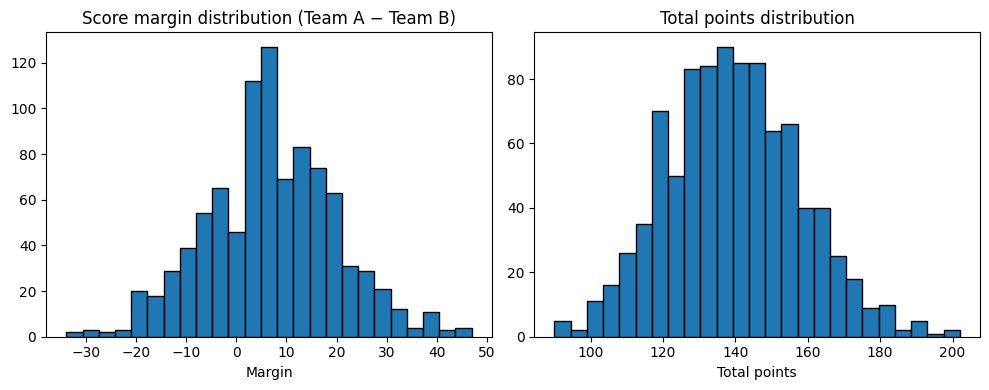

In [128]:
# 2.1 Quick exploration: distributions and correlations
import matplotlib.pyplot as plt
import seaborn as sns

# Use cleaned dataset from Phase 1
df = matchups_clean.copy()
print(f"Cleaned matchup dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Seasons: {int(df['season'].min())}–{int(df['season'].max())}")

# Basic description of targets
print("\nTargets describe():")
print(df[['score_margin', 'game_result', 'total_points']].describe())

# Simple correlation of key diffs with score_margin
key_diffs = [c for c in MODEL_FEATURE_COLS if c.endswith('_diff')][:8]
if key_diffs:
    corr = df[key_diffs + ['score_margin']].corr()['score_margin'].sort_values(ascending=False)
    print("\nCorrelation of features with score_margin:")
    print(corr)

# Optional: simple histogram for score_margin
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(df['score_margin'], bins=25, edgecolor='k')
ax[0].set_title('Score margin distribution (Team A − Team B)')
ax[0].set_xlabel('Margin')

ax[1].hist(df['total_points'], bins=25, edgecolor='k')
ax[1].set_title('Total points distribution')
ax[1].set_xlabel('Total points')
plt.tight_layout()
plt.show()

In [129]:
# 2.2 Train/validation split by season and baselines

# Use earlier seasons for training, later seasons for validation to mimic "predicting the future".
VAL_START_SEASON = 2023   # train on 2011–2022, validate on 2023–2025

train_df = df[df['season'] < VAL_START_SEASON].copy()
val_df   = df[df['season'] >= VAL_START_SEASON].copy()

print(f"Train seasons: {int(train_df['season'].min())}–{int(train_df['season'].max())}, rows = {len(train_df):,}")
print(f"Val   seasons: {int(val_df['season'].min())}–{int(val_df['season'].max())}, rows = {len(val_df):,}")

X_train = train_df[MODEL_FEATURE_COLS].values
y_train = train_df['game_result'].values
X_val   = val_df[MODEL_FEATURE_COLS].values
y_val   = val_df['game_result'].values

# Baseline 1: always pick Team A (favored by our construction)
always_A_pred = np.ones_like(y_val)
acc_always_A = (always_A_pred == y_val).mean()

# Baseline 2: seed-only rule – pick Team A if Team A has better (lower) seed, else Team B
# (in our dataset Team A is already the lower seed when seeds exist, so this is same as always_A
# except for games with missing seeds, where we fallback to winner-as-Team A convention).
seed_baseline_pred = np.ones_like(y_val)  # effectively the same in this setup
acc_seed = (seed_baseline_pred == y_val).mean()

# Baseline 3: random 50/50
rng = np.random.default_rng(RANDOM_STATE)
random_pred = rng.integers(0, 2, size=len(y_val))
acc_random = (random_pred == y_val).mean()

print(f"\nBaseline accuracies on validation seasons {VAL_START_SEASON}–{int(val_df['season'].max())}:")
print(f"  Always Team A wins        : {acc_always_A:.3f}")
print(f"  Seed-only baseline        : {acc_seed:.3f}")
print(f"  Random 50/50              : {acc_random:.3f}")

Train seasons: 2011–2022, rows = 726
Val   seasons: 2023–2025, rows = 198

Baseline accuracies on validation seasons 2023–2025:
  Always Team A wins        : 0.753
  Seed-only baseline        : 0.753
  Random 50/50              : 0.571


In [130]:
# 2.3 First model: logistic regression for game_result
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

# Simple L2-regularized logistic regression
log_reg = LogisticRegression(max_iter=1000, solver='lbfgs')
log_reg.fit(X_train, y_train)

val_pred_prob = log_reg.predict_proba(X_val)[:, 1]
val_pred      = (val_pred_prob > 0.5).astype(int)

acc_model = accuracy_score(y_val, val_pred)
auc_model = roc_auc_score(y_val, val_pred_prob)

print("\nLogistic regression performance on validation set:")
print(f"  Accuracy  : {acc_model:.3f}")
print(f"  ROC AUC   : {auc_model:.3f}")
print(f"  Improvement vs seed baseline: {acc_model - acc_seed:+.3f} absolute")


Logistic regression performance on validation set:
  Accuracy  : 0.753
  ROC AUC   : 0.754
  Improvement vs seed baseline: +0.000 absolute


In [131]:
# 2.6 Simple hyperparameter sweep for HistGradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

param_grid = [
    {'learning_rate': 0.05, 'max_depth': 2},
    {'learning_rate': 0.05, 'max_depth': 3},
    {'learning_rate': 0.1,  'max_depth': 2},
    {'learning_rate': 0.1,  'max_depth': 3},
]

best_acc = -1
best_params = None

print("\nHyperparameter sweep for HistGradientBoostingClassifier (validation 2023–2025):")
for params in param_grid:
    clf = HistGradientBoostingClassifier(random_state=RANDOM_STATE,
                                         learning_rate=params['learning_rate'],
                                         max_depth=params['max_depth'])
    clf.fit(X_train, y_train)
    probs = clf.predict_proba(X_val)[:, 1]
    preds = (probs > 0.5).astype(int)
    acc = accuracy_score(y_val, preds)
    auc = roc_auc_score(y_val, probs)
    print(f"  params={params} → acc={acc:.3f}, auc={auc:.3f}")
    if acc > best_acc:
        best_acc = acc
        best_params = (params, auc)

print(f"\nBest params by accuracy: {best_params[0]}, acc={best_acc:.3f}, auc={best_params[1]:.3f}")
print(f"Seed baseline acc: {acc_seed:.3f}")


Hyperparameter sweep for HistGradientBoostingClassifier (validation 2023–2025):
  params={'learning_rate': 0.05, 'max_depth': 2} → acc=0.768, auc=0.792
  params={'learning_rate': 0.05, 'max_depth': 3} → acc=0.773, auc=0.797
  params={'learning_rate': 0.1, 'max_depth': 2} → acc=0.773, auc=0.780
  params={'learning_rate': 0.1, 'max_depth': 3} → acc=0.763, auc=0.785

Best params by accuracy: {'learning_rate': 0.05, 'max_depth': 3}, acc=0.773, auc=0.797
Seed baseline acc: 0.753


In [132]:
# 2.4 Gradient-boosted trees for game_result
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

# Use the same train/val split and features defined earlier (X_train, y_train, X_val, y_val, MODEL_FEATURE_COLS)
print("\nTraining HistGradientBoostingClassifier on", len(MODEL_FEATURE_COLS), "features...")

gb_clf = HistGradientBoostingClassifier(random_state=RANDOM_STATE)
gb_clf.fit(X_train, y_train)

val_prob_gb = gb_clf.predict_proba(X_val)[:, 1]
val_pred_gb = (val_prob_gb > 0.5).astype(int)

acc_gb = accuracy_score(y_val, val_pred_gb)
auc_gb = roc_auc_score(y_val, val_prob_gb)

print("Gradient-boosted trees performance on validation set:")
print(f"  Accuracy  : {acc_gb:.3f}")
print(f"  ROC AUC   : {auc_gb:.3f}")
print(f"  Improvement vs seed baseline: {acc_gb - acc_seed:+.3f} absolute")
print(f"  Improvement vs logistic reg : {acc_gb - acc_model:+.3f} absolute")


Training HistGradientBoostingClassifier on 11 features...


Gradient-boosted trees performance on validation set:
  Accuracy  : 0.783
  ROC AUC   : 0.747
  Improvement vs seed baseline: +0.030 absolute
  Improvement vs logistic reg : +0.030 absolute


In [133]:
# 2.5 Simple ensemble: logistic regression + gradient-boosted trees
from sklearn.metrics import accuracy_score, roc_auc_score

# val_pred_prob  : logistic regression probabilities (from §2.3)
# val_prob_gb    : gradient-boosted trees probabilities (from §2.4)
# y_val, acc_seed, acc_gb, acc_model already defined above.

alpha = 0.5  # weight on boosted trees; 0.5 = simple average
val_prob_ens = alpha * val_prob_gb + (1 - alpha) * val_pred_prob
val_pred_ens = (val_prob_ens > 0.5).astype(int)

acc_ens = accuracy_score(y_val, val_pred_ens)
auc_ens = roc_auc_score(y_val, val_prob_ens)

print("Ensemble (0.5*GB + 0.5*LogReg) performance on validation set:")
print(f"  Accuracy  : {acc_ens:.3f}")
print(f"  ROC AUC   : {auc_ens:.3f}")
print(f"  Improvement vs seed baseline : {acc_ens - acc_seed:+.3f}")
print(f"  Improvement vs boosted trees : {acc_ens - acc_gb:+.3f}")
print(f"  Improvement vs logistic reg  : {acc_ens - acc_model:+.3f}")

Ensemble (0.5*GB + 0.5*LogReg) performance on validation set:
  Accuracy  : 0.763
  ROC AUC   : 0.763
  Improvement vs seed baseline : +0.010
  Improvement vs boosted trees : -0.020
  Improvement vs logistic reg  : +0.010


In [ ]:
---
### 2.7 Regression Models for Score Prediction (Engine Export)

Train `HistGradientBoostingRegressor` models for **score_margin** and **total_points**, then serialize them alongside the feature column list so the bracket engine can produce per-team score predictions without re-training.

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

y_margin_train = train_df['score_margin'].values
y_margin_val   = val_df['score_margin'].values
y_total_train  = train_df['total_points'].values
y_total_val    = val_df['total_points'].values

margin_model = HistGradientBoostingRegressor(
    learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE
)
margin_model.fit(X_train, y_margin_train)

total_model = HistGradientBoostingRegressor(
    learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE
)
total_model.fit(X_train, y_total_train)

margin_pred = margin_model.predict(X_val)
total_pred  = total_model.predict(X_val)

print("Score-margin regressor (validation):")
print(f"  MAE : {mean_absolute_error(y_margin_val, margin_pred):.2f}")
print(f"  R²  : {r2_score(y_margin_val, margin_pred):.3f}")
print(f"\nTotal-points regressor (validation):")
print(f"  MAE : {mean_absolute_error(y_total_val, total_pred):.2f}")
print(f"  R²  : {r2_score(y_total_val, total_pred):.3f}")

derived_a = (total_pred + margin_pred) / 2
derived_b = (total_pred - margin_pred) / 2
actual_a  = (y_total_val + y_margin_val) / 2
actual_b  = (y_total_val - y_margin_val) / 2
print(f"\nDerived per-team score MAE:  Team A = {mean_absolute_error(actual_a, derived_a):.2f},  Team B = {mean_absolute_error(actual_b, derived_b):.2f}")

In [ ]:
models_dir = DATA_DIR / "models"
models_dir.mkdir(exist_ok=True)

joblib.dump(margin_model, models_dir / "score_margin_model.pkl")
joblib.dump(total_model,  models_dir / "total_points_model.pkl")
joblib.dump(MODEL_FEATURE_COLS, models_dir / "feature_cols.pkl")

print(f"Exported to {models_dir}/:")
for p in sorted(models_dir.glob("*.pkl")):
    print(f"  {p.name}  ({p.stat().st_size / 1024:.0f} KB)")